# Connect to Big Query

In [ ]:
# import libraries
from google.cloud import bigquery
from google.colab import auth
# authenticate

auth.authenticate_user()

# init the client for BigQuery
proj_id = "employee-turnover-503115"
client = bigquery.Client(proj_id, location='EU')

In [ ]:
# Get the dataset and table

dataset_ref = client.dataset('employee_data', project=proj_id)
dataset = client.get_dataset(dataset_ref)
table_ref = dataset.table('tbl_hr_data')
table = client.get_table(table_ref)
table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None, None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None, None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None, None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None, None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None, None)]

In [ ]:
new_table_ref = dataset.table('tbl_new_employees')
new_table = client.get_table(new_table_ref)
new_table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None, None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None, None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None, None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None, None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None, None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None, None)]

In [ ]:
# convert to dataframes
df = client.list_rows(table).to_dataframe()
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2,157,3,0,1,0,sales,low,EMP00001
1,0.80,0.86,5,262,6,0,1,0,sales,medium,EMP00002
2,0.11,0.88,7,272,4,0,1,0,sales,medium,EMP00003
3,0.72,0.87,5,223,5,0,1,0,sales,low,EMP00004
4,0.37,0.52,2,159,3,0,1,0,sales,low,EMP00005


In [ ]:
df2 = client.list_rows(new_table).to_dataframe()
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


# Build a Model


In [ ]:
##Install sklearn
# !pip install scikit-learn

## Code and Train Model

In [ ]:
# Get the models
# Get random forest model
from sklearn.ensemble import RandomForestClassifier


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15004 entries, 0 to 15003
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     15004 non-null  float64
 1   last_evaluation        15004 non-null  float64
 2   number_project         14999 non-null  Int64  
 3   average_montly_hours   15004 non-null  Int64  
 4   time_spend_company     14999 non-null  Int64  
 5   Work_accident          15000 non-null  Int64  
 6   Quit_the_Company       15004 non-null  Int64  
 7   promotion_last_5years  15004 non-null  Int64  
 8   Departments            15004 non-null  object 
 9   salary                 15004 non-null  object 
 10  employee_id            15004 non-null  object 
dtypes: Int64(6), float64(2), object(3)
memory usage: 1.3+ MB


In [ ]:
# setup the dataframe
df_prepped = df.copy()

# set the target and ignore features and categorical features
df_prepped = df_prepped.drop(['employee_id'], axis=1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Define categorical features
categorical_features = ['salary', 'Departments']

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
encoded_features = encoder.fit_transform(df_prepped[categorical_features])

# Create a DataFrame from the encoded features with appropriate column names
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df_prepped.index)

# Concatenate the encoded features with the original dataframe and drop the original categorical columns
df_prepped = pd.concat([df_prepped.drop(columns=categorical_features), df_encoded], axis=1)

display(df_prepped.head())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,salary_high,salary_low,...,Departments_IT,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical
0,0.38,0.53,2,157,3,0,1,0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.80,0.86,5,262,6,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.11,0.88,7,272,4,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.72,0.87,5,223,5,0,1,0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.37,0.52,2,159,3,0,1,0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
rf_model = RandomForestClassifier(random_state=123)

In [ ]:
from sklearn.model_selection import train_test_split

# Define target and features
target = 'Quit_the_Company'
X = df_prepped.drop(columns=[target])
y = df_prepped[target]

# Split the data into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (10502, 20)
Testing features shape: (4502, 20)
Training target shape: (10502,)
Testing target shape: (4502,)


In [ ]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3429
         1.0       0.99      0.97      0.98      1073

    accuracy                           0.99      4502
   macro avg       0.99      0.98      0.99      4502
weighted avg       0.99      0.99      0.99      4502



# Predit the new data


In [ ]:
# Predit the new data in df2

## Prepare the df2 to be predicted
df2_prepped = df2.copy()
df2_prepped = df2_prepped.drop(['employee_id','Quit_the_Company'], axis=1)

# One hot encoder on df2
encoded_features = encoder.transform(df2_prepped[categorical_features])
df2_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df2_prepped.index)
df2_prepped = pd.concat([df2_prepped.drop(columns=categorical_features), df2_encoded], axis=1)

df2_prepped.head()



,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_high,salary_low,salary_medium,Departments_IT,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical
0,0.537849,0.122914,2,208,2,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.056211,0.322600,2,229,5,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.555186,0.555949,2,187,3,0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.605273,0.713086,2,218,3,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.043437,0.162372,2,175,3,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Make predictions

df2_pred = rf_model.predict(df2_prepped)

# Display the predictions
print("Predictions for new employees (1 = will quit, 0 = will not quit):")
print(df2_pred)

# Add the predictions back to the df2_prepped DataFrame for analysis
new_predicted = df2_prepped.copy()
new_predicted['prediction_label'] = df2_pred
display(new_predicted.head())

Predictions for new employees (1 = will quit, 0 = will not quit):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0.]


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_high,salary_low,salary_medium,...,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,prediction_label
0,0.537849,0.122914,2,208,2,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.056211,0.322600,2,229,5,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.555186,0.555949,2,187,3,0,0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.605273,0.713086,2,218,3,0,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.043437,0.162372,2,175,3,0,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import numpy as np

# Get the prediction probabilities for df2_prepped
# pred_proba returns an array with probabilities for each class [P(class 0), P(class 1)]

# The input to predict_proba should be the feature DataFrame (df2_prepped), not the 1D prediction array (df2_pred).
pred_proba = rf_model.predict_proba(df2_prepped)

# The probability of quitting is for class 1, which is the second column (index 1)
new_predicted['prediction_score'] = np.round(pred_proba[:, 1] * 100, 2)

display(new_predicted.head())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_high,salary_low,salary_medium,...,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,prediction_label,prediction_score
0,0.537849,0.122914,2,208,2,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.056211,0.322600,2,229,5,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0
2,0.555186,0.555949,2,187,3,0,0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,0.605273,0.713086,2,218,3,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.043437,0.162372,2,175,3,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0


In [ ]:
display(new_predicted)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_high,salary_low,salary_medium,...,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,prediction_label,prediction_score
0,0.537849,0.122914,2,208,2,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.056211,0.322600,2,229,5,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0
2,0.555186,0.555949,2,187,3,0,0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,0.605273,0.713086,2,218,3,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.043437,0.162372,2,175,3,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.205280,0.616096,6,153,3,1,1,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,11.0
96,0.976977,0.860386,6,296,3,0,0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,63.0
97,0.691851,0.389109,6,207,2,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
98,0.827268,0.779616,7,224,2,0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,38.0


In [ ]:
# export to google big query

new_predicted.to_gbq('employee_data.pilot_predictions',
                     proj_id,
                     chunksize=None,
                     if_exists='replace')

/tmp/ipykernel_2261/3231669558.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_gbq except for the argument 'destination_table' will be keyword-only.
  new_predicted.to_gbq('employee_data.pilot_predictions',
/tmp/ipykernel_2261/3231669558.py:3: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  new_predicted.to_gbq('employee_data.pilot_predictions',
100%|██████████| 1/1 [00:00<00:00, 13443.28it/s]


In [ ]:
# To analyze features that were most important for the prediction


### Feature Importance Analysis

To understand which features were most influential in the `RandomForestClassifier`'s predictions, we can examine its `feature_importances_` attribute. This attribute provides a score for each feature, indicating its relative importance in the model.

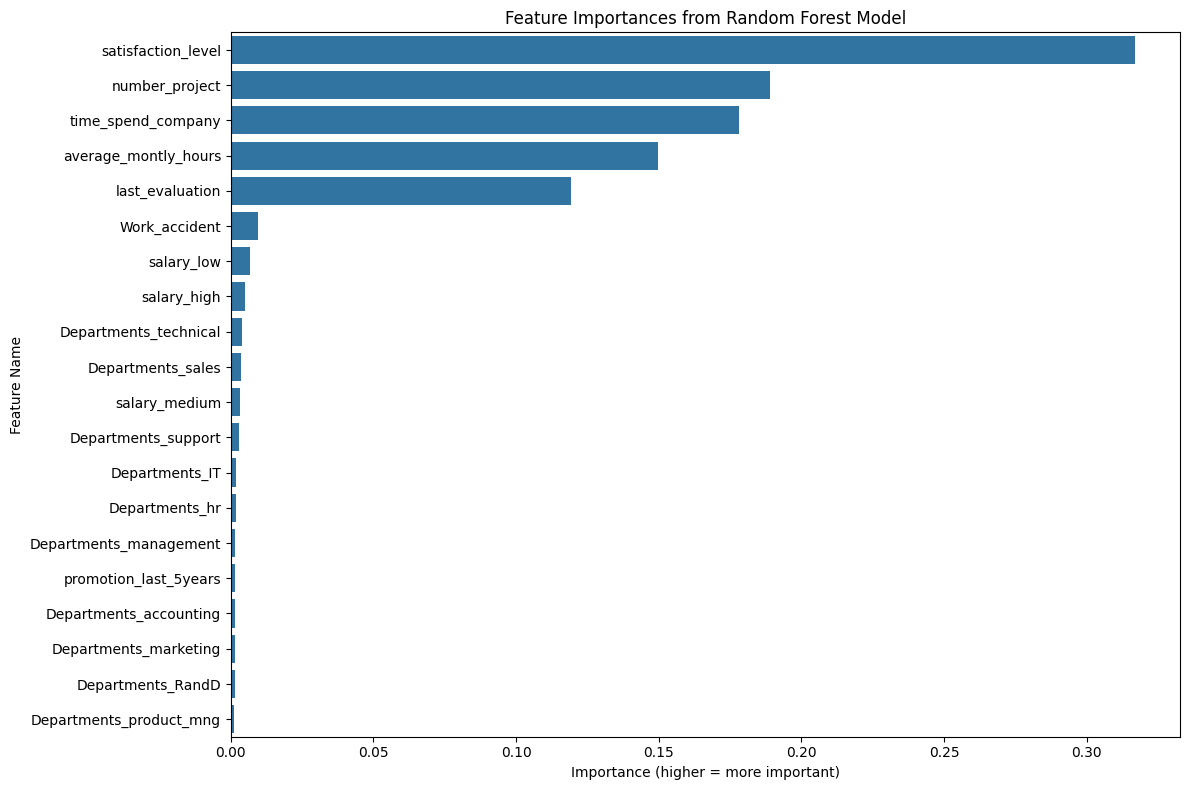

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get the feature names from X_train (which was used for training)
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest Model')
plt.xlabel('Importance (higher = more important)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
importance_df

,Feature,Importance
0,satisfaction_level,0.316801
2,number_project,0.189074
4,time_spend_company,0.178023
3,average_montly_hours,0.149749
1,last_evaluation,0.119105
5,Work_accident,0.009512
8,salary_low,0.006759
7,salary_high,0.004930
19,Departments_technical,0.003818
17,Departments_sales,0.003585


In [ ]:
# export to gbq
importance_df.to_gbq('employee_data.feature_table',
                     proj_id,
                     chunksize=None,
                     if_exists='replace')

/tmp/ipykernel_2261/1051244523.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_gbq except for the argument 'destination_table' will be keyword-only.
  importance_df.to_gbq('employee_data.feature_table',
/tmp/ipykernel_2261/1051244523.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  importance_df.to_gbq('employee_data.feature_table',
100%|██████████| 1/1 [00:00<00:00, 15307.68it/s]
